<a href="https://colab.research.google.com/github/Ali13fffff/hotel-booking-cancellation-analysis/blob/main/another_copy_of_untitled31.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving booking.csv to booking.csv


#Import libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Load Data

In [10]:
df=pd.read_csv("booking.csv")
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64
 14  specia

#Cleaning Data

In [11]:
print(df.isnull().sum())
print(df.duplicated().sum())
df = df.drop_duplicates()
print(df["Booking_ID"].is_unique)
df=df.drop(columns=["Booking_ID"])

Booking_ID                  0
number of adults            0
number of children          0
number of weekend nights    0
number of week nights       0
type of meal                0
car parking space           0
room type                   0
lead time                   0
market segment type         0
repeated                    0
P-C                         0
P-not-C                     0
average price               0
special requests            0
date of reservation         0
booking status              0
dtype: int64
0
True


#Creating a new feature for analyzing the target column

In [12]:


status_mapping = {
    "Canceled": 1,
    "Not_Canceled": 0,
}

df = df.copy()

df["total_nights"] = (
    df["number of weekend nights"].fillna(0)
    + df["number of week nights"].fillna(0)
)

#total_revenue represents estimated potential revenue, not actual realized revenue.
df["total_revenue"] = (
    df["total_nights"]
    * df["average price"].fillna(0)
)

df["booking_status_number"] = df["booking status"].map(status_mapping)

#Analysis of Booking Status

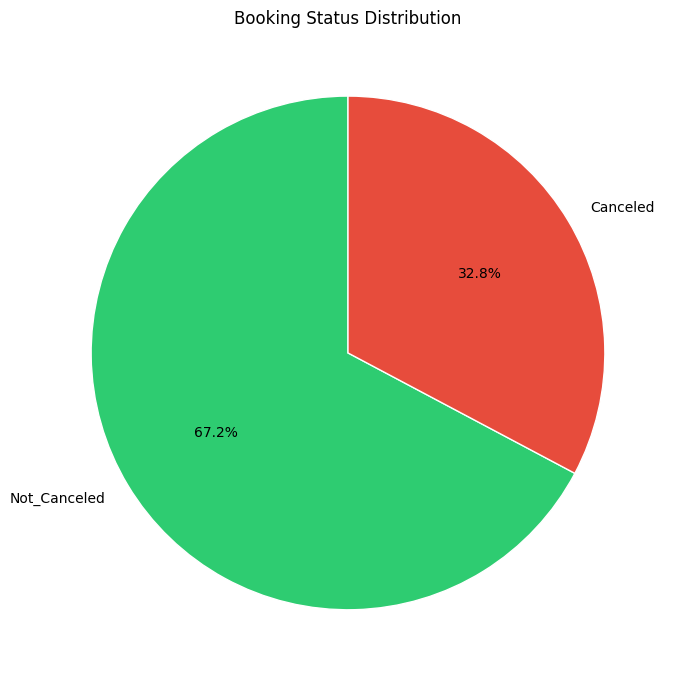

In [13]:

booking_status = (
    df["booking status"]
    .value_counts()
    .reindex(["Not_Canceled", "Canceled"])
)




plt.figure(figsize=(7, 7))
plt.pie(
    booking_status.values,
    labels=booking_status.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2ecc71", "#e74c3c"],
    wedgeprops={"edgecolor": "white", "linewidth": 1},
)
plt.title("Booking Status Distribution")
plt.tight_layout()
plt.show()

#The dataset is moderately imbalanced toward non-canceled bookings, with approximately two-thirds of bookings not canceled and one-third canceled.
Further analysis can examine variables such as lead time, length of stay, room type, market segment type, and booking-related characteristics.

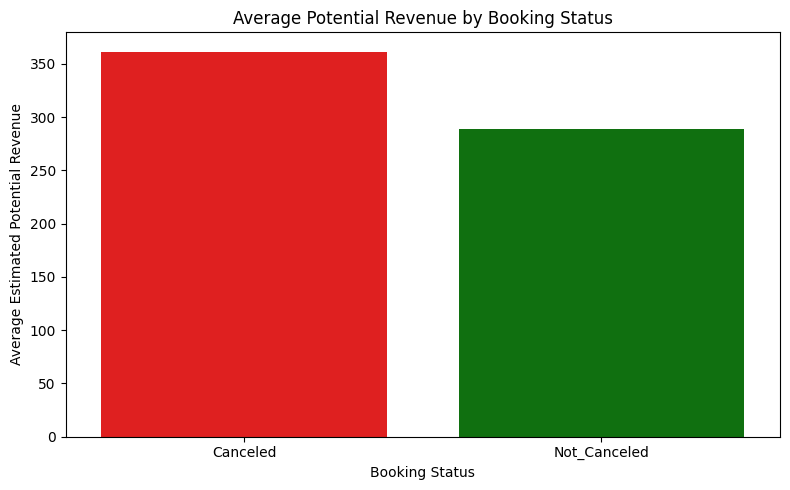

In [14]:
average_revenue_by_status = (
    df.groupby("booking status")["total_revenue"]
    .mean()
    .reset_index(name="average_potential_revenue")
)

status_palette = {
    "Not_Canceled": "green",
    "Canceled": "red",
}

plt.figure(figsize=(8, 5))

sns.barplot(
    data=average_revenue_by_status,
    x="booking status",
    y="average_potential_revenue",
    hue="booking status",
    palette=status_palette,
    legend=False
)

plt.title("Average Potential Revenue by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Average Estimated Potential Revenue")
plt.tight_layout()
plt.show()

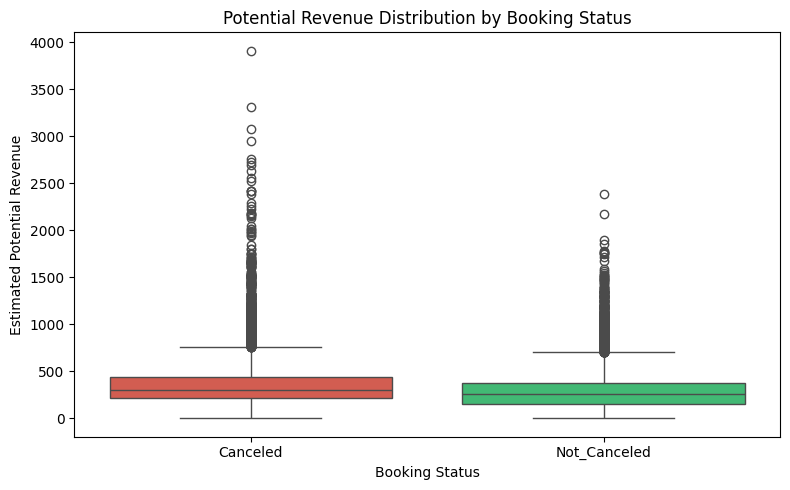

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="booking status",
    y="total_revenue",
    hue="booking status",
    order=["Canceled", "Not_Canceled"],
    hue_order=["Canceled", "Not_Canceled"],
    palette={
        "Canceled": "#e74c3c",
        "Not_Canceled": "#2ecc71"
    },
    legend=False
)
plt.title("Potential Revenue Distribution by Booking Status")
plt.xlabel("Booking Status")
plt.ylabel("Estimated Potential Revenue")
plt.tight_layout()
plt.show()

#The boxplot shows that canceled bookings have more outliers than non-canceled bookings, indicating greater variability in potential revenue. However, the medians of the two groups are relatively similar. Therefore, the main difference between the groups is related to the outliers rather than their typical revenue values.

#Key Business Insight:
Although most bookings are confirmed, canceled reservations still represent a significant potential revenue loss for the hotel. The average potential revenue of canceled bookings is notably higher than that of non-canceled bookings, suggesting that high-value reservations may be at greater risk of cancellation.

#Categorical Features Analysis

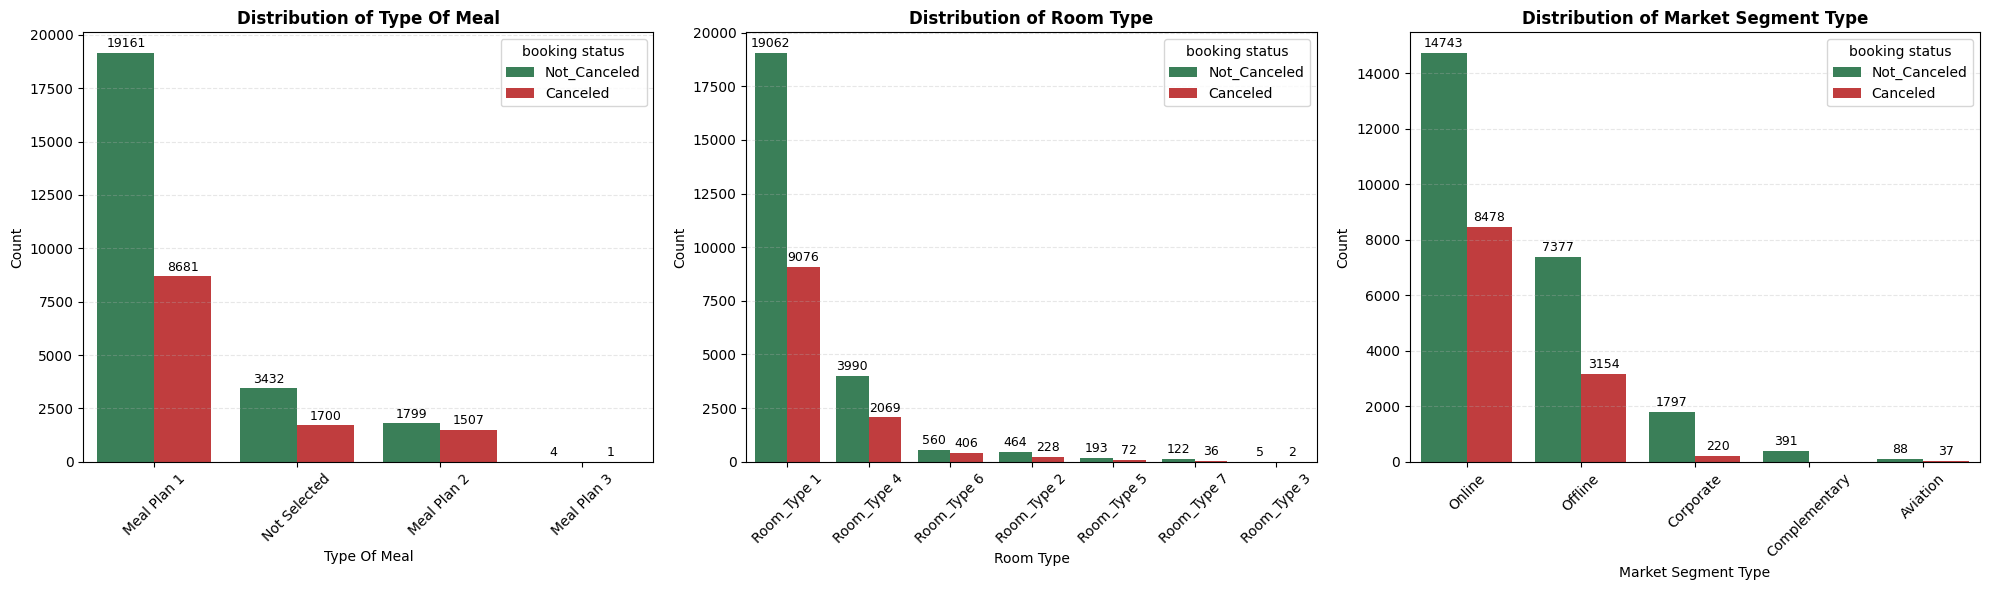

In [16]:

categorical_features = [
    "type of meal",
    "room type",
    "market segment type"
]

palette = {"Not_Canceled": "#2E8B57", "Canceled": "#D62728"}


fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6), sharey=False)

for i, col in enumerate(categorical_features):
    ax = axes[i]


    sns.countplot(
        data=df,
        x=col,
        hue="booking status",
        palette=palette,
        ax=ax,
        order=df[col].value_counts().index # مرتب‌سازی از بیشترین به کمترین
    )

    ax.set_title(f"Distribution of {col.title()}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col.title(), fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", linestyle="--", alpha=0.3)


    for container in ax.containers:
        ax.bar_label(container, fontsize=9, padding=2)

plt.tight_layout()
plt.show()

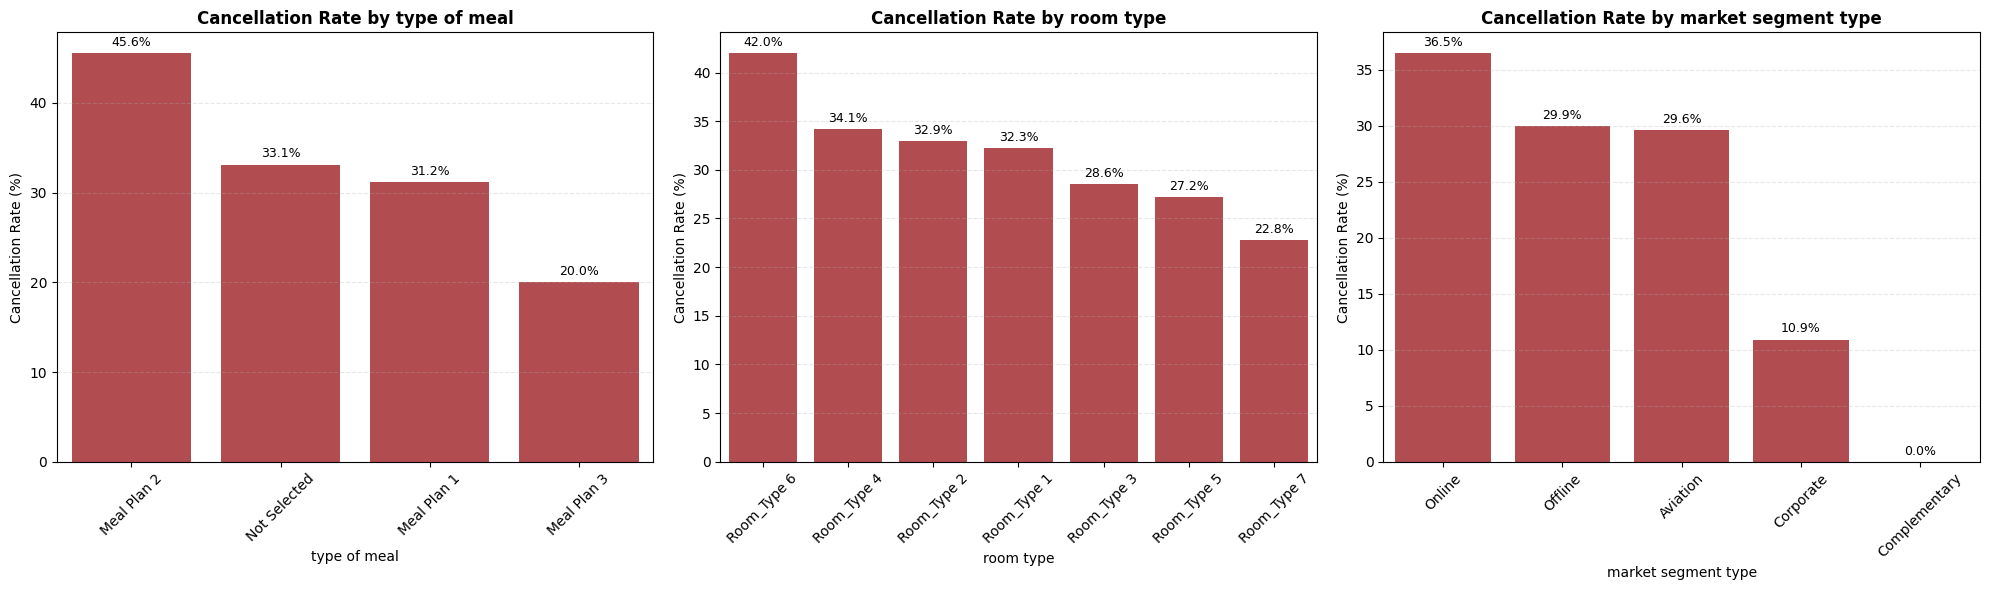

In [17]:


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(20, 6)
)

for i, col in enumerate(categorical_features):
    ax = axes[i]


    cancellation_rate = (
        df.groupby(col)["booking_status_number"]
          .mean()
          .sort_values(ascending=False)
          .reset_index()
    )

    cancellation_rate["booking_status_number"] *= 100

    sns.barplot(
        data=cancellation_rate,
        x=col,
        y="booking_status_number",
        color="#C23B40",
        ax=ax
    )

    ax.set_title(
        f"Cancellation Rate by {col}",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel(col)
    ax.set_ylabel("Cancellation Rate (%)")

    ax.tick_params(
        axis="x",
        rotation=45
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )


    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f%%",
            padding=3,
            fontsize=9
        )

plt.tight_layout()
plt.show()

#Categorical Feature Analysis:

The analysis shows that Meal Plan 1, Room Type 1, and the Online market segment have the highest number of bookings in their respective categories. This indicates that these are the most common meal plan, room type, and booking channel in the dataset.

Regarding cancellation rates, Meal Plan 2 has the highest cancellation rate among the meal plan categories. Room Type 6 shows the highest cancellation rate among the room types, while the Online market segment has the highest cancellation rate among the major market segments.

Some categories, such as Meal Plan 3, Room Type 3, and Aviation, contain relatively few bookings. Therefore, their cancellation rates should be interpreted cautiously because small sample sizes can produce unstable results.
These findings provide useful initial insights into booking behavior and cancellation risk.
 However, cancellation rates should be interpreted together with booking volume and sample size. Further analysis of numerical variables such as lead time, total nights, average price, and special requests may help identify the strongest factors associated with cancellations.

#Converting the date attribute to the appropriate format

In [18]:


df['date of reservation'] = pd.to_datetime(df['date of reservation'], errors='coerce')

#Monthly Booking Volume and Cancellation Patterns Across All Years

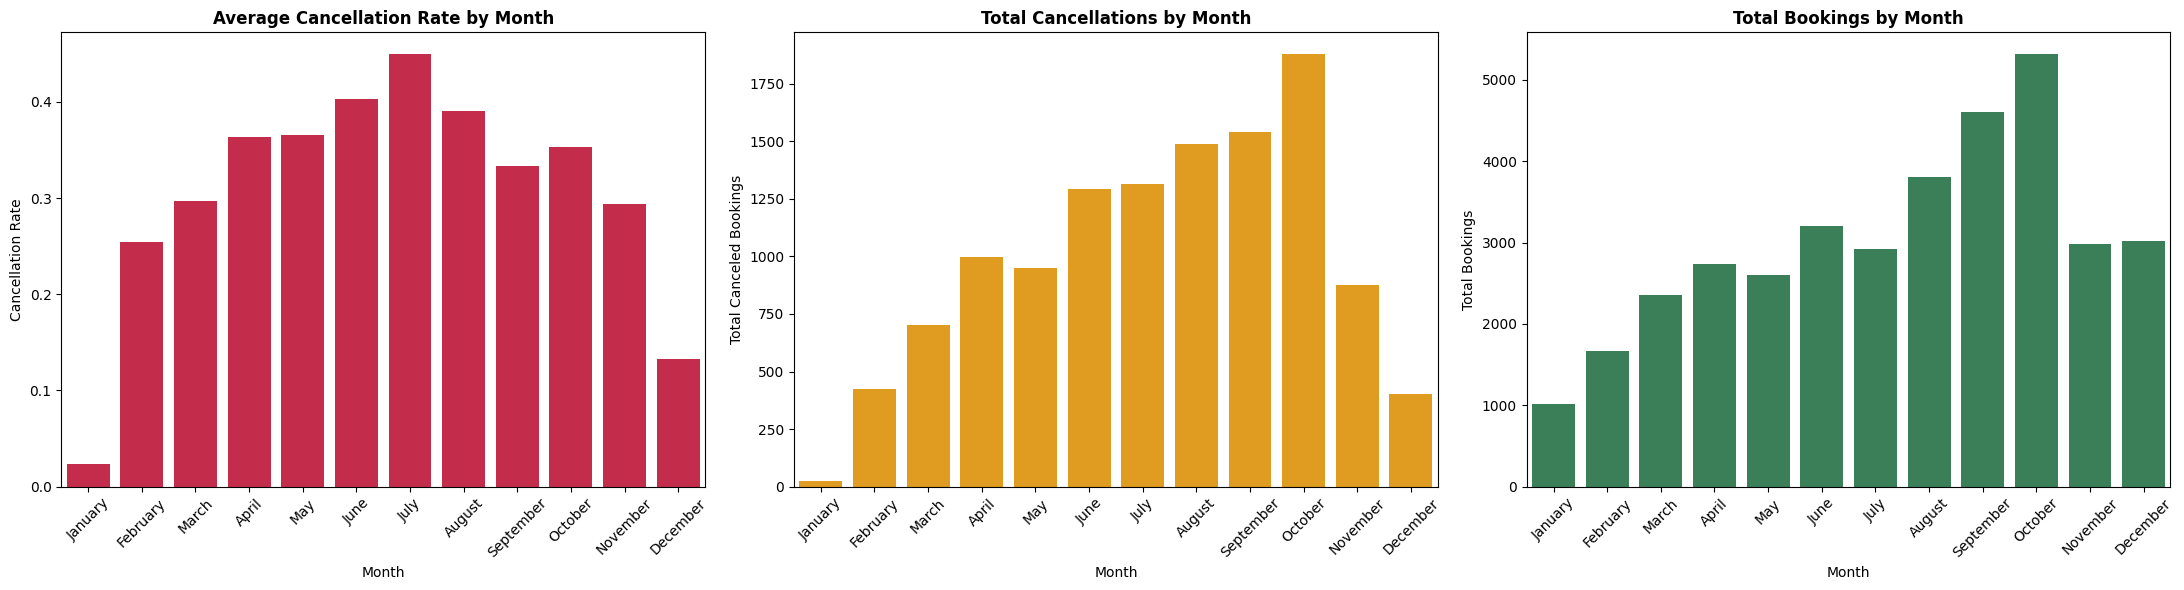

In [19]:

df["month_num"] = df["date of reservation"].dt.month
df["month_name"] = df["date of reservation"].dt.month_name()


monthly_summary = (
    df.groupby(["month_num", "month_name"])
    .agg(
        cancellation_rate=("booking_status_number", "mean"),
        total_cancellations=("booking_status_number", "sum"),
        total_bookings=("booking_status_number", "size")
    )
    .reset_index()
    .sort_values("month_num")
)


fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="cancellation_rate",
    ax=axes[0],
    color="crimson"
)

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="total_cancellations",
    ax=axes[1],
    color="orange"
)

sns.barplot(
    data=monthly_summary,
    x="month_name",
    y="total_bookings",
    ax=axes[2],
    color="seagreen"
)

titles = [
    "Average Cancellation Rate by Month",
    "Total Cancellations by Month",
    "Total Bookings by Month"
]

for ax, title in zip(axes, titles):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Cancellation Rate")
axes[1].set_ylabel("Total Canceled Bookings")
axes[2].set_ylabel("Total Bookings")

plt.tight_layout()
plt.show()

#August, September, and October have the highest booking volumes and therefore also account for the highest numbers of cancellations. July has the highest cancellation rate relative to its total number of bookings, indicating a higher cancellation risk in proportion to booking volume. These results are based on the reservation date and should not be interpreted as definitive evidence of the hotel's tourist season.

#Lead Time Analysis

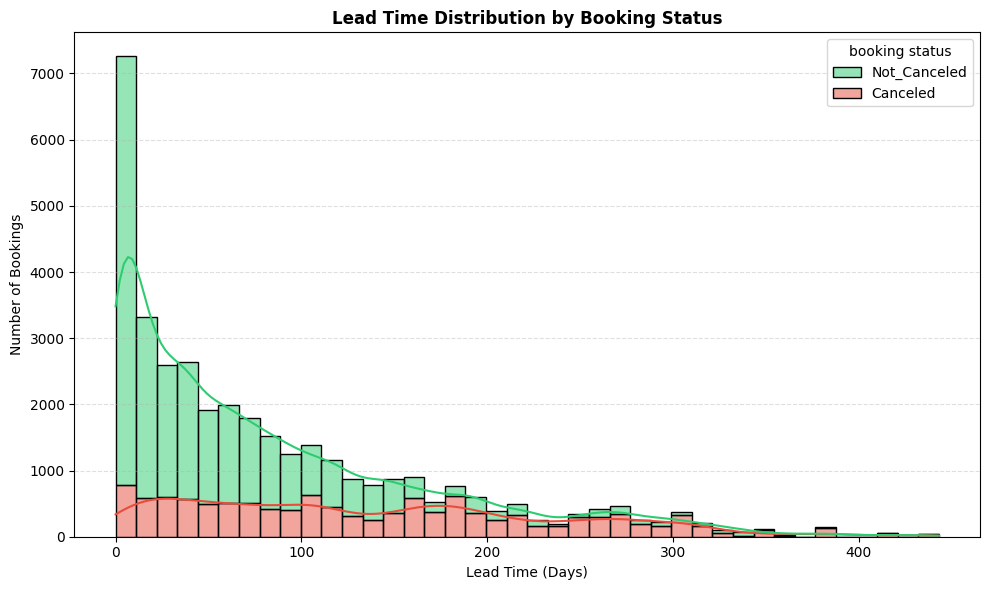

In [20]:

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="lead time",
    hue="booking status",
    bins=40,
    kde=True,
    multiple="stack",
    common_norm=False,
    palette={
        "Not_Canceled": "#2ecc71",
        "Canceled": "#e74c3c"
    }
)

plt.title(
    "Lead Time Distribution by Booking Status",
    fontweight="bold"
)

plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [21]:

df["lead_time_range"] = pd.cut(
    df["lead time"],
    bins=[0, 30, 60, 100, 150, 200, 300, 500],
    include_lowest=True
)

lead_time_analysis = (
    df.groupby("lead_time_range", observed=False)
      .agg(
          total_bookings=("booking_status_number", "count"),
          canceled_bookings=("booking_status_number", "sum")
      )
      .reset_index()
)

lead_time_analysis["cancellation_rate"] = (
    lead_time_analysis["canceled_bookings"]
    / lead_time_analysis["total_bookings"]
    * 100
)

lead_time_analysis

,lead_time_range,total_bookings,canceled_bookings,cancellation_rate
0,"(-0.001, 30.0]",12413,1764,14.210908
1,"(30.0, 60.0]",6310,1481,23.470681
2,"(60.0, 100.0]",5668,1661,29.304869
3,"(100.0, 150.0]",4610,1766,38.308026
4,"(150.0, 200.0]",3159,2133,67.521368
5,"(200.0, 300.0]",3000,2169,72.300000
6,"(300.0, 500.0]",1125,915,81.333333


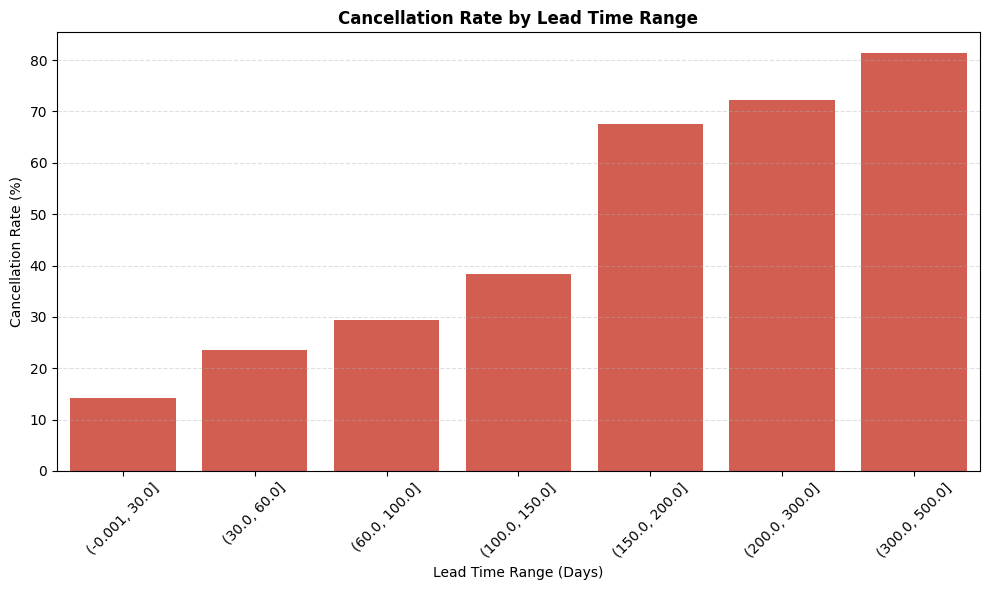

In [22]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=lead_time_analysis,
    x="lead_time_range",
    y="cancellation_rate",
    color="#e74c3c"
)

plt.title(
    "Cancellation Rate by Lead Time Range",
    fontweight="bold"
)
plt.xlabel("Lead Time Range (Days)")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Lead Time and Cancellation Analysis

The histogram shows that the `lead time` distribution is strongly right-skewed. Most hotel bookings were made within a short period before arrival, especially between 0 and 5 days. As the lead time increases, the total number of bookings gradually decreases.

Although the number of bookings becomes lower at higher lead time values, the distribution of `Canceled` bookings becomes relatively higher than the distribution of `Not_Canceled` bookings from around 100 days onward. This indicates that bookings made far in advance may have a higher risk of cancellation.

The cancellation rate chart confirms this pattern more clearly. It shows a stepwise increase in the cancellation rate as the lead time becomes longer. Therefore, there is a positive relationship between lead time and booking cancellation rate: bookings made further in advance are more likely to be canceled.

From a business perspective, bookings with a very long lead time should be managed more carefully because they carry a higher cancellation risk. For example, the hotel can request an advance payment or deposit for bookings made more than 100 days in advance. For extremely long lead times, such as bookings made more than 300 days ahead, a stricter cancellation policy or cancellation penalty can be considered to reduce potential losses.

In addition, the hotel can send reminder messages or confirmation emails before the arrival date to reduce uncertainty and encourage guests to keep their bookings. Offering non-refundable rates for long lead time reservations may also help the hotel secure revenue earlier and lower the cancellation rate.

All lead time groups contain a sufficient number of observations. Therefore, the results provide a reasonable basis for identifying lead time as an important factor related to hotel booking cancellations. However, other variables should also be considered before concluding that lead time is the only cause of cancellations.

#Repeated Guest Analysis

In [23]:


repeated_counts = df['repeated'].value_counts()
repeated_shares = df['repeated'].value_counts(normalize=True) * 100

print("--- Value Counts ---")
print(repeated_counts)
print("\n--- Share Percentages (%) ---")
print(repeated_shares.round(2))


ct_counts = pd.crosstab(df['repeated'], df['booking status'], margins=True)
ct_percentages = pd.crosstab(df['repeated'], df['booking status'], normalize='index') * 100

print("\n--- Crosstab (Counts) ---")
print(ct_counts)
print("\n--- Cancellation Rate by repeated (%) ---")
print(ct_percentages.round(2))

--- Value Counts ---
repeated
0    35355
1      930
Name: count, dtype: int64

--- Share Percentages (%) ---
repeated
0    97.44
1     2.56
Name: proportion, dtype: float64

--- Crosstab (Counts) ---
booking status  Canceled  Not_Canceled    All
repeated                                     
0                  11873         23482  35355
1                     16           914    930
All                11889         24396  36285

--- Cancellation Rate by repeated (%) ---
booking status  Canceled  Not_Canceled
repeated                              
0                  33.58         66.42
1                   1.72         98.28


/tmp/ipykernel_3314/59048788.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['New (0)', 'Repeated (1)'])
/tmp/ipykernel_3314/59048788.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['New (0)', 'Repeated (1)'])


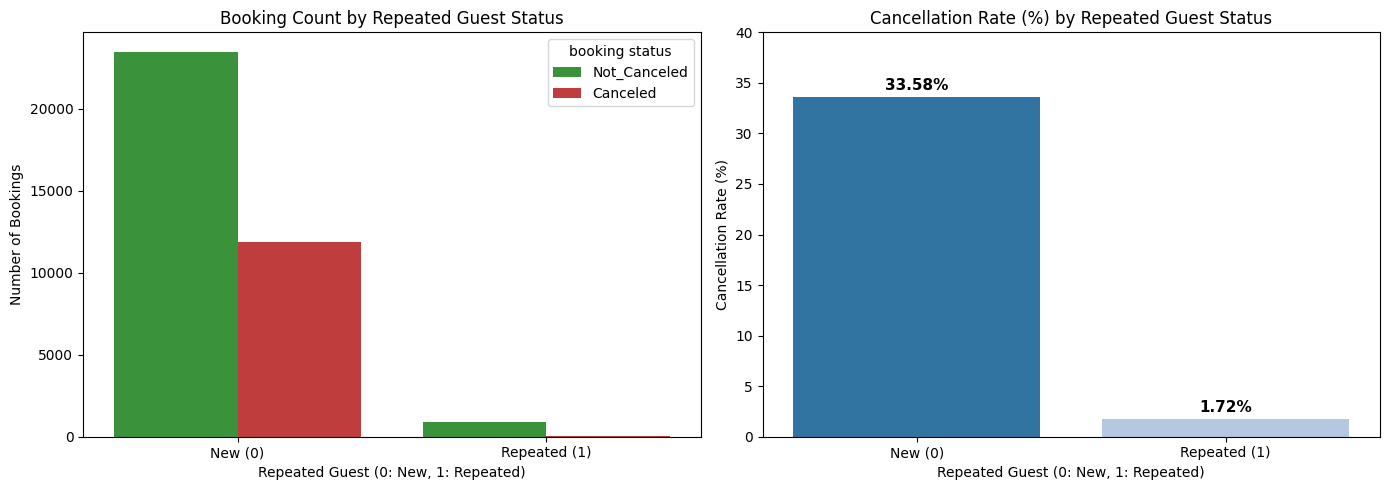

In [24]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(
    data=df,
    x='repeated',
    hue='booking status',
    ax=axes[0],
    palette=['#2ca02c', '#d62728']
)

axes[0].set_title('Booking Count by Repeated Guest Status')
axes[0].set_xlabel('Repeated Guest (0: New, 1: Repeated)')
axes[0].set_ylabel('Number of Bookings')
axes[0].set_xticklabels(['New (0)', 'Repeated (1)'])


cancel_rate = (
    df.groupby('repeated')['booking_status_number']
    .mean()
    .mul(100)
    .reset_index(name='cancellation_rate')
)

sns.barplot(
    data=cancel_rate,
    x='repeated',
    y='cancellation_rate',
    ax=axes[1],
    hue='repeated',
    palette=['#1f77b4', '#aec7e8'],
    legend=False
)

axes[1].set_title('Cancellation Rate (%) by Repeated Guest Status')
axes[1].set_xlabel('Repeated Guest (0: New, 1: Repeated)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(['New (0)', 'Repeated (1)'])
axes[1].set_ylim(0, 40)


for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

#Analysis of Repeated Guests
According to the charts and numerical results, most hotel bookings are made by new guests. Approximately 97% of the bookings belong to first-time customers, while only about 3% are made by repeated guests. This is an important finding because it shows that the hotel depends mainly on attracting new customers rather than relying on returning ones.

This suggests that the hotel should pay special attention to new guests and design incentive policies to encourage them to book again in the future. Loyalty programs, discounts for future stays, and a better first-time guest experience may help increase repeat bookings over time.

At the same time, cancellation control is also important because the cancellation rate among new guests is relatively high. About 33% of bookings from new guests are canceled, while repeated guests have a very low cancellation rate of only 1.72%. This means that repeated
guests are much more reliable, but the hotel’s main cancellation risk comes from new customers.

Therefore, the hotel should not only focus on attracting new guests but also apply policies that reduce cancellation risk, such as confirmation reminders, advance payment, or more controlled cancellation rules for first-time bookings.

#Analysis of car parking space

In [25]:

parking_counts = df['car parking space'].value_counts(dropna=False)
parking_shares = df['car parking space'].value_counts(normalize=True) * 100

print("--- Value Counts ---")
print(parking_counts)
print("\n--- Share Percentages (%) ---")
print(parking_shares.round(2))


ct_parking_counts = pd.crosstab(df['car parking space'], df['booking status'], margins=True)
ct_parking_percentages = pd.crosstab(df['car parking space'], df['booking status'], normalize='index') * 100

print("\n--- Crosstab (Counts) ---")
print(ct_parking_counts)
print("\n--- Cancellation Rate by car parking space (%) ---")
print(ct_parking_percentages.round(2))

--- Value Counts ---
car parking space
0    35161
1     1124
Name: count, dtype: int64

--- Share Percentages (%) ---
car parking space
0    96.9
1     3.1
Name: proportion, dtype: float64

--- Crosstab (Counts) ---
booking status     Canceled  Not_Canceled    All
car parking space                               
0                     11775         23386  35161
1                       114          1010   1124
All                   11889         24396  36285

--- Cancellation Rate by car parking space (%) ---
booking status     Canceled  Not_Canceled
car parking space                        
0                     33.49         66.51
1                     10.14         89.86


/tmp/ipykernel_3314/3385722248.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['No (0)', 'Yes (1)'])
/tmp/ipykernel_3314/3385722248.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No (0)', 'Yes (1)'])


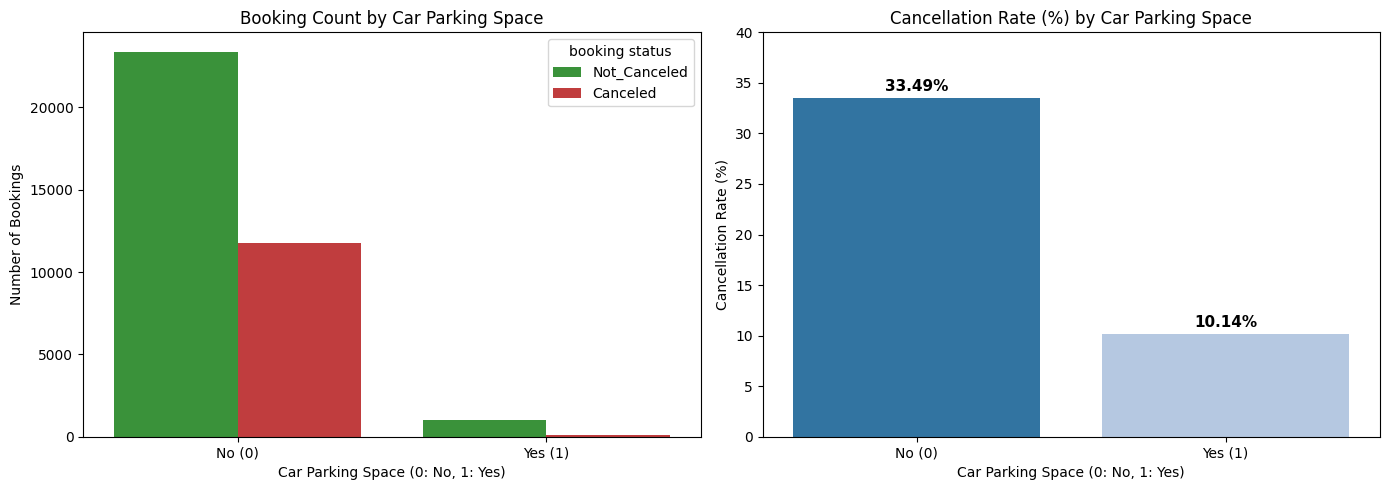

In [26]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(
    data=df,
    x='car parking space',
    hue='booking status',
    ax=axes[0],
    palette=['#2ca02c', '#d62728']
)

axes[0].set_title('Booking Count by Car Parking Space')
axes[0].set_xlabel('Car Parking Space (0: No, 1: Yes)')
axes[0].set_ylabel('Number of Bookings')
axes[0].set_xticklabels(['No (0)', 'Yes (1)'])


cancel_rate_parking = (
    df.groupby('car parking space')['booking_status_number']
    .mean()
    .mul(100)
    .reset_index(name='cancellation_rate')
)

sns.barplot(
    data=cancel_rate_parking,
    x='car parking space',
    y='cancellation_rate',
    ax=axes[1],
    hue='car parking space',
    palette=['#1f77b4', '#aec7e8'],
    legend=False
)

axes[1].set_title('Cancellation Rate (%) by Car Parking Space')
axes[1].set_xlabel('Car Parking Space (0: No, 1: Yes)')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticklabels(['No (0)', 'Yes (1)'])
axes[1].set_ylim(0, 40)


for p in axes[1].patches:
    axes[1].annotate(
        f"{p.get_height():.2f}%",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        xytext=(0, 3),
        textcoords='offset points'
    )

plt.tight_layout()
plt.show()

The car parking space column shows an imbalanced distribution in relative terms. Although the number of bookings with a parking request is 1,124, which is not small in absolute terms, they account for only about 3% of the total dataset. Most bookings, around 96%, did not include a parking request.

Despite representing a small share of the dataset, this feature appears to be related to booking cancellation behavior. The cancellation rate among guests who requested parking is about 10%, while it is around 30% among guests who did not request parking. This suggests that parking requests may be associated with more committed or better-planned bookings.

From a business perspective, car parking space can be treated as a useful indicator of booking confidence. Reservations with parking requests may deserve faster confirmation or more proactive service. However, because the
parking-request group is much smaller than the non-parking group, the results should still be interpreted carefully and considered alongside other booking features.

In [33]:


df['previous_cancellation_group'] = np.where(
    df['P-C'] == 0,
    'No Previous Cancellation',
    'At Least One Previous Cancellation'
)


summary = df.groupby('previous_cancellation_group').agg(
    total_bookings=('booking_status_number', 'count'),
    total_canceled=('booking_status_number', 'sum'),
    cancellation_rate=('booking_status_number', 'mean')
)

summary['cancellation_rate'] = summary['cancellation_rate'] * 100
print("--- Statistical Summary ---")
print(summary.round(2))


crosstab_table = pd.crosstab(
    df['previous_cancellation_group'],
    df['booking status']
)

print("\n--- Crosstab Counts ---")
print(crosstab_table)


crosstab_percentage = pd.crosstab(
    df['previous_cancellation_group'],
    df['booking status'],
    normalize='index'
) * 100

print("\n--- Crosstab Percentages ---")
print(crosstab_percentage.round(2))

--- Statistical Summary ---
                                    total_bookings  total_canceled  \
previous_cancellation_group                                          
At Least One Previous Cancellation             338              16   
No Previous Cancellation                     35947           11873   

                                    cancellation_rate  
previous_cancellation_group                            
At Least One Previous Cancellation               4.73  
No Previous Cancellation                        33.03  

--- Crosstab Counts ---
booking status                      Canceled  Not_Canceled
previous_cancellation_group                               
At Least One Previous Cancellation        16           322
No Previous Cancellation               11873         24074

--- Crosstab Percentages ---
booking status                      Canceled  Not_Canceled
previous_cancellation_group                               
At Least One Previous Cancellation      4.73         95.27

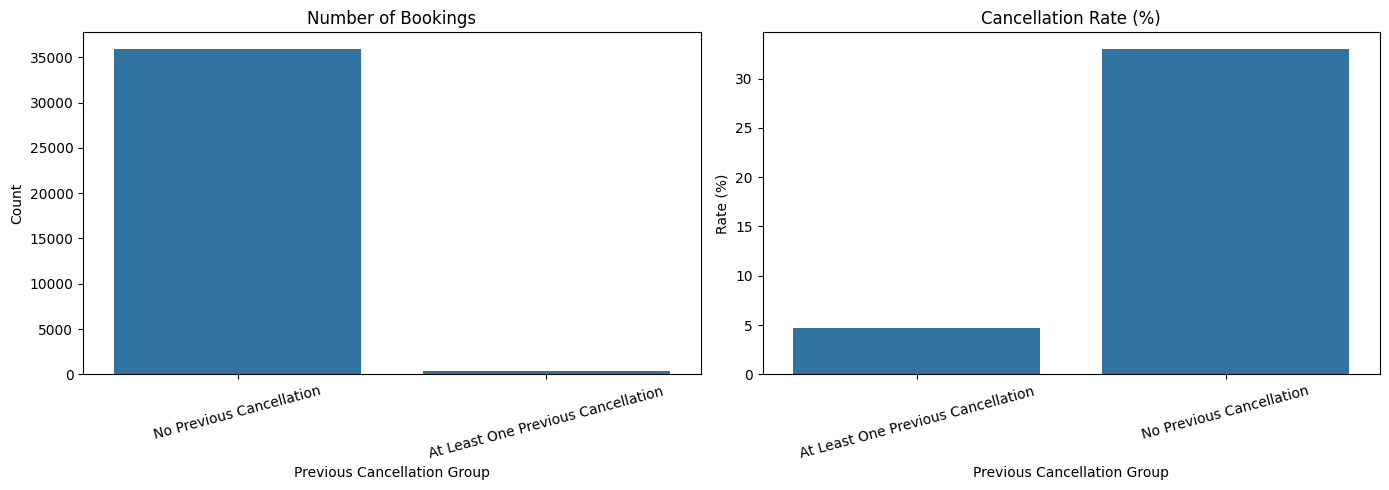

In [35]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(
    data=df,
    x='previous_cancellation_group',
    order=df['previous_cancellation_group'].value_counts().index,
    ax=axes[0]
)
axes[0].set_title('Number of Bookings')
axes[0].set_xlabel('Previous Cancellation Group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)


rate_df = df.groupby('previous_cancellation_group')['booking_status_number'].mean().reset_index()
rate_df['booking_status_number'] = rate_df['booking_status_number'] * 100

sns.barplot(
    data=rate_df,
    x='previous_cancellation_group',
    y='booking_status_number',
    ax=axes[1]
)
axes[1].set_title('Cancellation Rate (%)')
axes[1].set_xlabel('Previous Cancellation Group')
axes[1].set_ylabel('Rate (%)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

#In this dataset, customers who had at least one previous cancellation surprisingly showed a lower cancellation rate in their current booking. This means that previous cancellation history is not always a direct sign of future cancellation risk. However, because this group is much smaller than the no-history group, the result should be used carefully. The hotel should combine this feature with other booking indicators before making operational decisions.